In [28]:
import os, time, copy, random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import (EfficientNet_B0_Weights, EfficientNet_B1_Weights,
                                EfficientNet_B2_Weights, EfficientNet_B3_Weights)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

In [30]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

device: cuda NVIDIA GeForce RTX 5070 Ti


In [32]:
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(42)

EPOCHS       = 15
IMG_SIZE     = 32
NUM_WORKERS  = 0

In [33]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15, 0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
test_ds  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

classes = train_ds.classes

In [5]:
class MiniCNN(nn.Module):
    def __init__(self, num_classes=10, emb_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.embedding  = nn.Linear(128, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x, return_embedding=False):
        f = self.features(x).flatten(1)
        e = self.embedding(f)
        return e if return_embedding else self.classifier(e)

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = correct = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

In [7]:
def train_model(model, train_loader, test_loader, epochs=3, lr=3e-4, tag='model'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        tl = tc = tt = 0
        pbar = tqdm(train_loader, desc=f'[{tag}] {epoch+1}/{epochs}')
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            tl += loss.item() * x.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += x.size(0)
            pbar.set_postfix(loss=tl/tt, acc=tc/tt)
        scheduler.step()

        _, val_acc = evaluate(model, test_loader, criterion)
        print(f'[{tag}] epoch {epoch+1}: train_acc={tc/tt:.4f}  val_acc={val_acc:.4f}')
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, best_acc

In [8]:
def build_efficientnet(name='b0', num_classes=10, in_size=32):
    ctor, weights = {
        'b0': (models.efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        'b1': (models.efficientnet_b1, EfficientNet_B1_Weights.DEFAULT),
        'b2': (models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
        'b3': (models.efficientnet_b3, EfficientNet_B3_Weights.DEFAULT),
    }[name]
    m = ctor(weights=weights)

    old_conv = m.features[0][0]
    new_conv = nn.Conv2d(3, old_conv.out_channels, kernel_size=3,
                         stride=1, padding=1, bias=False)
    with torch.no_grad():
        w = old_conv.weight
        if w.shape[-1] != 3:
            w = F.adaptive_avg_pool2d(w, (3, 3))
        new_conv.weight.copy_(w)
    m.features[0][0] = new_conv

    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, num_classes)
    return m

results, trained_models = {}, {}

In [9]:
# set_seed(42)
# mini = MiniCNN(num_classes=10, emb_dim=128)
# mini, acc_mini = train_model(mini, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, tag='MiniCNN')
# trained_models['MiniCNN'] = mini
# results['MiniCNN'] = acc_mini

In [10]:
# for name in ['b0', 'b1', 'b2', 'b3']:
#     set_seed(42)
#     model = build_efficientnet(name, num_classes=10, in_size=IMG_SIZE)
#     lr = {'b0': 3e-4, 'b1': 2e-4, 'b2': 2e-4, 'b3': 1.5e-4}[name]
#     tag = f'EfficientNet-{name.upper()}'
#     model, acc = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=lr, tag=tag)
#     trained_models[tag] = model
#     results[tag] = acc

In [11]:
for name in ['b3']:
    set_seed(42)
    model = build_efficientnet(name, num_classes=10, in_size=IMG_SIZE)
    lr = {'b0': 3e-4,'b3': 1.5e-4}[name]
    tag = f'EfficientNet-{name.upper()}'
    model, acc = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=lr, tag=tag)
    trained_models[tag] = model
    results[tag] = acc

[EfficientNet-B3] 1/25: 100%|██████████| 391/391 [00:24<00:00, 16.26it/s, acc=0.494, loss=1.63]


[EfficientNet-B3] epoch 1: train_acc=0.4944  val_acc=0.7629


[EfficientNet-B3] 2/25: 100%|██████████| 391/391 [00:23<00:00, 16.58it/s, acc=0.743, loss=1.1] 


[EfficientNet-B3] epoch 2: train_acc=0.7428  val_acc=0.8416


[EfficientNet-B3] 3/25: 100%|██████████| 391/391 [00:23<00:00, 16.60it/s, acc=0.804, loss=0.959]


...

[EfficientNet-B3] epoch 23: train_acc=0.9611  val_acc=0.9368


[EfficientNet-B3] 24/25: 100%|██████████| 391/391 [00:23<00:00, 16.30it/s, acc=0.961, loss=0.596]


[EfficientNet-B3] epoch 24: train_acc=0.9614  val_acc=0.9367


[EfficientNet-B3] 25/25: 100%|██████████| 391/391 [00:24<00:00, 16.08it/s, acc=0.963, loss=0.593]


[EfficientNet-B3] epoch 25: train_acc=0.9635  val_acc=0.9368


In [12]:
print('\n=== Точность на тесте ===')
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{k:20s}  acc = {v:.4f}')


=== Точность на тесте ===
EfficientNet-B3       acc = 0.9374


In [13]:
@torch.no_grad()
def extract_embeddings(model, loader, model_type='mini'):
    model.eval()
    E, L, I = [], [], []
    for x, y in loader:
        x = x.to(device)
        if model_type == 'mini':
            e = model(x, return_embedding=True)
        else:
            f = model.features(x)
            e = model.avgpool(f).flatten(1)
        E.append(e.cpu()); L.append(y); I.append(x.cpu())
    E = F.normalize(torch.cat(E), dim=1)
    return E, torch.cat(L), torch.cat(I)

# mini_embs, mini_labels, mini_imgs = extract_embeddings(mini, test_loader, 'mini')
b3_embs,   b3_labels,   b3_imgs   = extract_embeddings(trained_models['EfficientNet-B3'], test_loader, 'eff')

In [15]:
def to_img(t):
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

def show_top5(q_idx, embs, labels, imgs, title, topk=5):
    q = embs[q_idx:q_idx+1]
    sims = (embs @ q.T).squeeze(1)
    sims[q_idx] = -1e9
    top = sims.topk(topk).indices.tolist()

    fig, axes = plt.subplots(1, topk+1, figsize=(2.6*(topk+1), 2.8))
    axes[0].imshow(to_img(imgs[q_idx]))
    axes[0].set_title(f'QUERY\n{classes[labels[q_idx]]}', fontsize=10)
    axes[0].axis('off')
    for i, j in enumerate(top):
        axes[i+1].imshow(to_img(imgs[j]))
        ok = 'OK' if labels[j] == labels[q_idx] else 'X'
        axes[i+1].set_title(f'{ok} {classes[labels[j]]}\nsim={sims[j]:.3f}', fontsize=9)
        axes[i+1].axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

# for q_idx in [0, 10, 25]:
#     print(f'\n### Query idx={q_idx}, класс = {classes[mini_labels[q_idx]]}')
#     # show_top5(q_idx, mini_embs, mini_labels, mini_imgs, 'MiniCNN (128D)')
#     # show_top5(q_idx, b0_embs,   b0_labels,   b0_imgs,   'EfficientNet-B0 (1280D)')
#     show_top5(q_idx, b3_embs,   b3_labels,   b3_imgs,   'EfficientNet-B3 (1536D)')

In [16]:
def retrieval_metrics(embs, labels, topk=5):
    sims = embs @ embs.T
    sims.fill_diagonal_(-1e9)
    top = sims.topk(topk, dim=1).indices
    correct = (labels[top] == labels.unsqueeze(1))
    return correct.any(1).float().mean().item(), correct.float().mean().item()

print(f'\n{"Модель":20s} {"top5 hit":>10s} {"prec@5":>10s}')
for name, (e, l) in {
    # 'MiniCNN':         (mini_embs, mini_labels),
    'EfficientNet-B3': (b3_embs,   b3_labels),
}.items():
    h, p = retrieval_metrics(e, l, topk=5)
    print(f'{name:20s} {h:10.4f} {p:10.4f}')


Модель                 top5 hit     prec@5
EfficientNet-B3          0.9692     0.9207


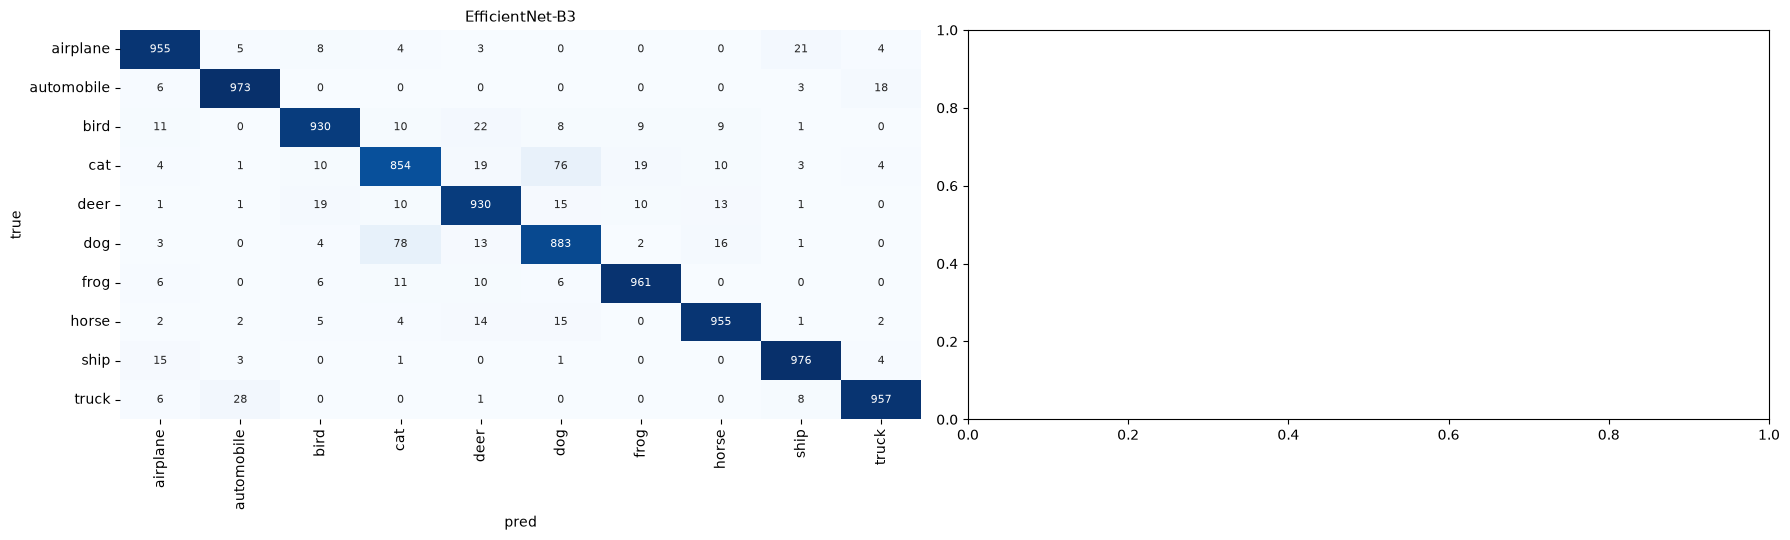

In [19]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    P, L = [], []
    for x, y in loader:
        x = x.to(device)
        P.append(model(x).argmax(1).cpu())
        L.append(y)
    return torch.cat(P).numpy(), torch.cat(L).numpy()

models_dict = {
    # 'MiniCNN':         trained_models['MiniCNN'],
    'EfficientNet-B3': trained_models['EfficientNet-B3'],
}

preds = {name: get_predictions(m, test_loader) for name, m in models_dict.items()}

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
for ax, (name, (p, l)) in zip(axes, preds.items()):
    cm = confusion_matrix(l, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=False, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

In [ ]:
Заморозка весов efficient net и обучение только классификатора

In [34]:
class EfficientNetB3CIFAR(nn.Module):
    def __init__(
        self,
        num_classes=10,
        pretrained=True,
        freeze_features=False,
    ):
        super().__init__()

        weights = (
            EfficientNet_B3_Weights.IMAGENET1K_V1
            if pretrained
            else None
        )

        self.net = models.efficientnet_b3(
            weights=weights,
        )

        self.net.features[0][0].stride = (1, 1)

        self.embedding_dim = self.net.classifier[1].in_features

        self.net.classifier[1] = nn.Linear(
            self.embedding_dim,
            num_classes,
        )

        self.freeze_features = freeze_features

        if self.freeze_features:
            for parameter in self.net.features.parameters():
                parameter.requires_grad = False

    def forward(
        self,
        x,
        return_embedding=False,
    ):
        x = self.net.features(x)
        x = self.net.avgpool(x)

        embedding = torch.flatten(
            x,
            1,
        )

        if return_embedding:
            return embedding

        return self.net.classifier(
            embedding
        )

In [35]:
CONFIGS = {
    "EfficientNet-B3-Finetune": {
        "lr": 2e-4,
        "freeze": False,
    },
    "EfficientNet-B3-Frozen": {
        "lr": 1e-3,
        "freeze": True,
    },
}

In [36]:
def build_model(
    name,
    pretrained=True,
):
    config = CONFIGS[name]

    return EfficientNetB3CIFAR(
        pretrained=pretrained,
        freeze_features=config["freeze"],
    )

In [37]:
def train_epoch(
    model,
    data_loader,
    optimizer,
    frozen=False,
):
    if frozen:
        model.eval()
        model.net.classifier.train()
    else:
        model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(
        data_loader,
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True,
        )

        outputs = model(
            images
        )

        loss = F.cross_entropy(
            outputs,
            labels,
        )

        loss.backward()
        optimizer.step()

        total += labels.size(0)

        loss_sum += (
            loss.item()
            * labels.size(0)
        )

        correct += (
            outputs.argmax(dim=1)
            == labels
        ).sum().item()

    loss = loss_sum / total
    accuracy = correct / total

    return loss, accuracy

In [38]:
@torch.no_grad()
def evaluate(
    model,
    data_loader,
):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    predictions = []
    targets = []

    for images, labels in data_loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels_device = labels.to(
            DEVICE,
            non_blocking=True,
        )

        outputs = model(
            images
        )

        loss = F.cross_entropy(
            outputs,
            labels_device,
            reduction="sum",
        )

        loss_sum += loss.item()
        total += labels.size(0)

        prediction = outputs.argmax(
            dim=1
        )

        correct += (
            prediction == labels_device
        ).sum().item()

        predictions.append(
            prediction.cpu()
        )

        targets.append(
            labels
        )

    loss = loss_sum / total
    accuracy = correct / total

    predictions = torch.cat(
        predictions
    ).numpy()

    targets = torch.cat(
        targets
    ).numpy()

    return (
        loss,
        accuracy,
        predictions,
        targets,
    )

In [39]:
def train_model(
    name,
    train_loader,
):
    model = build_model(
        name,
        pretrained=True,
    ).to(DEVICE)

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=CONFIGS[name]["lr"],
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
    )

    frozen = CONFIGS[name]["freeze"]

    history = []

    for epoch in range(EPOCHS):
        current_lr = optimizer.param_groups[0]["lr"]

        loss, accuracy = train_epoch(
            model,
            train_loader,
            optimizer,
            frozen=frozen,
        )

        scheduler.step()

        history.append(
            {
                "epoch": epoch + 1,
                "loss": loss,
                "accuracy": accuracy,
                "lr": current_lr,
            }
        )

        print(
            f"{name} | "
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

    return (
        model,
        pd.DataFrame(history),
    )

In [40]:
trained_models = {}
histories = {}

for name in CONFIGS:
    model, history = train_model(
        name,
        train_loader,
    )

    trained_models[name] = model
    histories[name] = history

EfficientNet-B3-Finetune | Epoch 1/15 | Loss: 1.2987 | Accuracy: 0.5471


EfficientNet-B3-Finetune | Epoch 2/15 | Loss: 0.6518 | Accuracy: 0.7750


EfficientNet-B3-Finetune | Epoch 3/15 | Loss: 0.4987 | Accuracy: 0.8279


EfficientNet-B3-Finetune | Epoch 4/15 | Loss: 0.4106 | Accuracy: 0.8567


EfficientNet-B3-Finetune | Epoch 5/15 | Loss: 0.3447 | Accuracy: 0.8803


...

EfficientNet-B3-Frozen | Epoch 11/15 | Loss: 1.4669 | Accuracy: 0.4857


EfficientNet-B3-Frozen | Epoch 12/15 | Loss: 1.4683 | Accuracy: 0.4902


EfficientNet-B3-Frozen | Epoch 13/15 | Loss: 1.4683 | Accuracy: 0.4891


EfficientNet-B3-Frozen | Epoch 14/15 | Loss: 1.4670 | Accuracy: 0.4883


EfficientNet-B3-Frozen | Epoch 15/15 | Loss: 1.4703 | Accuracy: 0.4907


In [42]:
from sklearn.metrics import f1_score

results = []

for name, model in trained_models.items():
    loss, accuracy, predictions, targets = evaluate(
        model,
        test_loader,
    )

    macro_f1 = f1_score(
        targets,
        predictions,
        average="macro",
    )

    results.append(
        {
            "model": name,
            "test_loss": loss,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
        }
    )

results_df = pd.DataFrame(
    results
)

display(
    results_df.round(4)
)

,model,test_loss,accuracy,macro_f1
0,EfficientNet-B3-Finetune,0.2187,0.9291,0.9290
1,EfficientNet-B3-Frozen,1.1711,0.6071,0.6022


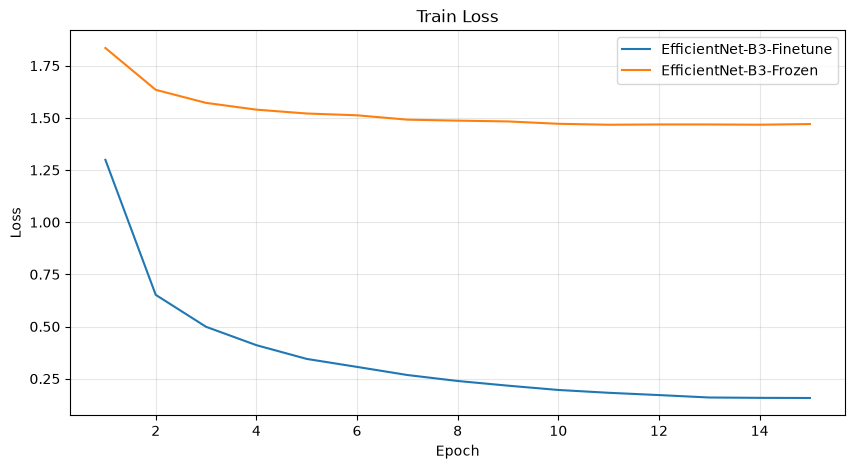

In [43]:
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(
        history["epoch"],
        history["loss"],
        label=name,
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

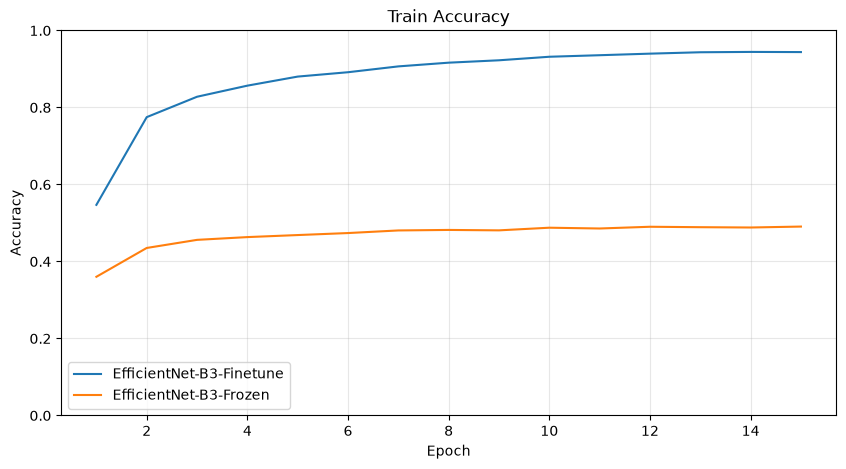

In [44]:
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(
        history["epoch"],
        history["accuracy"],
        label=name,
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()